In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn._loss import loss
from sklearn.datasets import make_blobs

dimension de X (100, 2)
dimension de y (100, 1)


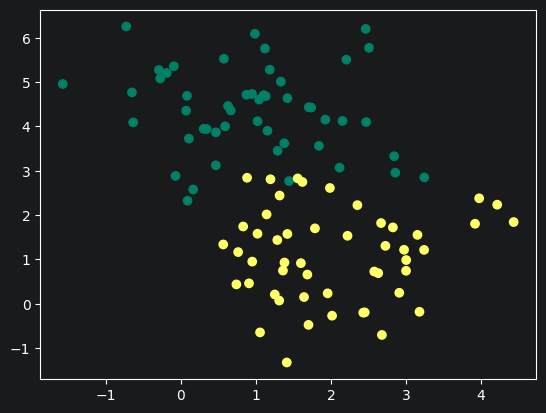

In [2]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape(y.shape[0], 1)
print("dimension de X", X.shape)
print("dimension de y", y.shape)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="summer")
plt.show()

In [3]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

In [32]:
W, b = initialisation(X)
W.shape

(2, 1)

In [85]:
def model(X, W, b):
    Z = X.dot(W) + b 
    A = 1 / (1 + np.exp(-Z))
    return A

In [86]:
A = model(X, W, b)
A.shape

(100, 1)

In [87]:
def log_loss(A, y):
    epsilon = 1e-15
    return 1 / len(y) * np.sum(-y * np.log(A + epsilon) - (1 - y) * np.log(1 - A + epsilon))
    

In [88]:

log_loss(A, y)

np.float64(1.193042683423984)

In [89]:
def gradient(A, X, y):
    dw = 1/len(y)*np.dot(X.T, (A - y))
    db = 1/len(y)*np.sum(A - y)
    return dw, db


In [90]:
dw, db = gradient(A, X, y)
dw.shape

(2, 1)

In [91]:
def update(dw, db, W, b, learning_rate):
    W -= learning_rate * dw
    b -= learning_rate * db
    return W, b

In [92]:
 def  artificial_neuron(X, y, learning_rate= 0.1, n_iter=100):
     W, b = initialisation(X)
     loss = []
     for i in range(n_iter):
        A = model(X, W, b)
        loss.append(log_loss(A, y))
        dw, db = gradient(A, X, y)
        W, b = update(dw, db, W, b, learning_rate)

     plt.plot(loss)
     plt.show()


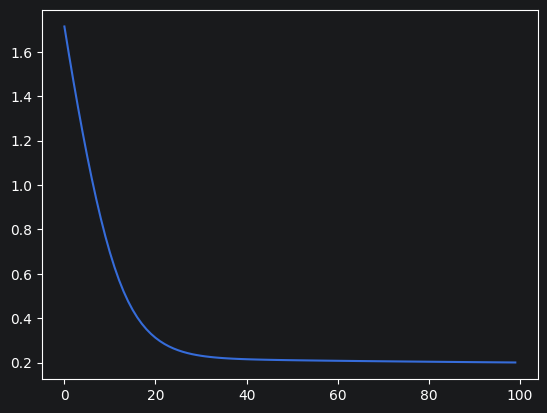

In [93]:
artificial_neuron(X, y)